# The Efficient Frontier (Section 2.1)

Following Markowitz (1952), the investor solves the constrained problem (2.1):

$$\min_{\boldsymbol{w}} \ \tfrac{1}{2}\,\boldsymbol{w}^{\top}\Sigma\,\boldsymbol{w}
\quad \text{subject to} \quad \boldsymbol{1}^{\top}\boldsymbol{w}=1,\quad \boldsymbol{\mu}^{\top}\boldsymbol{w}=R_{\min}.$$

Writing $A = \boldsymbol{1}^{\top}\Sigma^{-1}\boldsymbol{1}$, $B = \boldsymbol{1}^{\top}\Sigma^{-1}\boldsymbol{\mu}$, $C = \boldsymbol{\mu}^{\top}\Sigma^{-1}\boldsymbol{\mu}$, the optimal weights are the affine two-fund solution (2.2):

$$\boldsymbol{w}^{\star}(R_{\min})
= \frac{C - R_{\min}B}{AC - B^{2}}\,\Sigma^{-1}\boldsymbol{1}
+ \frac{R_{\min}A - B}{AC - B^{2}}\,\Sigma^{-1}\boldsymbol{\mu}.$$

As $R_{\min}$ varies, $\boldsymbol{w}^{\star}(R_{\min})$ traces out the frontier, whose variance is

$$\sigma^{2}(R_{\min}) = \frac{A\,R_{\min}^{2} - 2B\,R_{\min} + C}{AC - B^{2}},$$

minimised at the **global minimum-variance portfolio**: $R_{\mathrm{gmv}} = B/A$ with variance $\sigma^{2}_{\mathrm{gmv}} = 1/A$ (volatility $1/\sqrt{A}$), and $\boldsymbol{w}_{\mathrm{gmv}} = \Sigma^{-1}\boldsymbol{1}/A$.

The figure below is **purely illustrative**: the inputs $(\boldsymbol{\mu}, \Sigma)$ are arbitrary and the axes carry no numerical scale — the point is the shape of the frontier and the fact that changing $R_{\min}$ moves the optimal portfolio along it.

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Arbitrary illustrative inputs (any mu, positive-definite Sigma gives the same picture)
mu = np.array([0.06, 0.08, 0.10, 0.12, 0.15])
vols = np.array([0.12, 0.15, 0.18, 0.22, 0.28])
corr = 0.25 * np.ones((5, 5)) + 0.75 * np.eye(5)
Sigma = np.outer(vols, vols) * corr

ones = np.ones(len(mu))
Sigma_inv = np.linalg.inv(Sigma)

A = ones @ Sigma_inv @ ones
B = ones @ Sigma_inv @ mu
C = mu @ Sigma_inv @ mu
Delta = A * C - B**2

def w_star(R_min):
    # Two-fund solution (2.2)
    return ((C - R_min * B) / Delta) * (Sigma_inv @ ones) \
         + ((R_min * A - B) / Delta) * (Sigma_inv @ mu)

def frontier_sigma(R_min):
    return np.sqrt((A * R_min**2 - 2 * B * R_min + C) / Delta)

R_gmv, sigma_gmv = B / A, 1 / np.sqrt(A)   # variance at the GMV is 1/A

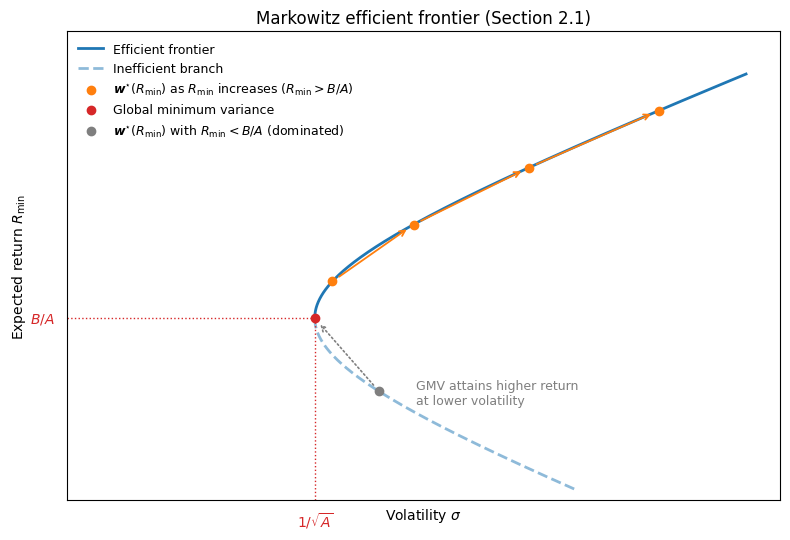

In [55]:
R_grid = np.linspace(R_gmv - 0.07, R_gmv + 0.10, 400)
sig_grid = frontier_sigma(R_grid)
efficient = R_grid >= R_gmv

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(sig_grid[efficient], R_grid[efficient], color="tab:blue", lw=2,
        label="Efficient frontier")
ax.plot(sig_grid[~efficient], R_grid[~efficient], color="tab:blue", lw=2,
        ls="--", alpha=0.5, label="Inefficient branch")

# The portfolio moves along the frontier as R_min increases
R_marks = np.linspace(R_gmv + 0.015, R_gmv + 0.085, 4)
ax.scatter(frontier_sigma(R_marks), R_marks, color="tab:orange", zorder=5,
           label=r"$\boldsymbol{w}^{\star}(R_{\min})$ as $R_{\min}$ increases ($R_{\min} > B/A$)")
for i in range(len(R_marks) - 1):
    ax.annotate("", xy=(frontier_sigma(R_marks[i+1]), R_marks[i+1]),
                xytext=(frontier_sigma(R_marks[i]), R_marks[i]),
                arrowprops=dict(arrowstyle="->", color="tab:orange", lw=1.3,
                                shrinkA=6, shrinkB=6))

# Global minimum-variance portfolio, with dotted guides to the axes
ax.scatter(sigma_gmv, R_gmv, color="tab:red", zorder=6, label="Global minimum variance")
ax.plot([0, sigma_gmv], [R_gmv, R_gmv], color="tab:red", ls=":", lw=1)
ax.plot([sigma_gmv, sigma_gmv], [0, R_gmv], color="tab:red", ls=":", lw=1)
ax.text(sigma_gmv, -0.004, r"$1/\sqrt{A}$", ha="center", va="top", color="tab:red")
ax.text(-0.005, R_gmv, r"$B/A$", ha="right", va="center", color="tab:red")

# A target below B/A lands on the dominated branch: the GMV itself
# offers strictly higher return at strictly lower volatility
R_bad = R_gmv - 0.03
ax.scatter(frontier_sigma(R_bad), R_bad, color="tab:gray", zorder=5,
           label=r"$\boldsymbol{w}^{\star}(R_{\min})$ with $R_{\min} < B/A$ (dominated)")
ax.annotate("", xy=(sigma_gmv, R_gmv), xytext=(frontier_sigma(R_bad), R_bad),
            arrowprops=dict(arrowstyle="->", color="tab:gray", lw=1.2, ls=":",
                            shrinkA=6, shrinkB=6))
ax.text(frontier_sigma(R_bad) + 0.015, R_bad + 0.005,
        "GMV attains higher return\nat lower volatility",
        color="tab:gray", fontsize=9, va="top", ha="left")

# Schematic axes: no numerical scale
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(0, sig_grid.max() * 1.05)
ax.set_ylim(0, R_grid.max() * 1.1)
ax.set_xlabel(r"Volatility $\sigma$")
ax.set_ylabel(r"Expected return $R_{\min}$", labelpad=28)
ax.set_title("Markowitz efficient frontier (Section 2.1)")
ax.legend(frameon=False, loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig("efficient_frontier.png", dpi=200, bbox_inches="tight")
plt.show()

**Reading the figure.** Each orange point is the optimal portfolio $\boldsymbol{w}^{\star}(R_{\min})$ for one value of $R_{\min}$; raising the target return moves the portfolio up along the efficient branch, at the cost of higher volatility. Only targets $R_{\min} > B/A$ are efficient. A target below $B/A$ (grey point) still solves (2.1), but lands on the dominated branch: the global minimum-variance portfolio at $(1/\sqrt{A},\, B/A)$ delivers a strictly higher return at strictly lower volatility, so no rational mean--variance investor would choose it.